In [9]:
import os
import time
import warnings

# Data manipulation and analysis
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from skimage.measure import EllipseModel

# Astropy modules
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import regions

# Matplotlib for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Ellipse

# Scipy and related modules
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences

# Spectral cube handling
from spectral_cube import SpectralCube as sc

# Progress bar
from tqdm.notebook import trange

# Additional libraries
from kneed import KneeLocator

# Multithreading
from joblib import Parallel, delayed

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})
delta_min = 1e-12

# %matplotlib widget

In [10]:
# Define the source and target cube patterns
crafts_pattern = "./CRAFTS_RA{ra}_DEC-13_2_cor_smo_{sign}.fits"

# Define RA ranges and signs
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
signs = ["+", "-"]
moments = [0, 1, 2]

ra = ra_ranges[0]
sign = signs[1]

crafts_file = crafts_pattern.format(ra=ra, sign=sign)

cube = sc.read(crafts_file).with_spectral_unit(u.km / u.s)
velocities = cube.spectral_axis.value
data = cube.unmasked_data[:, :, :].value
cube

SpectralCube with shape=(16, 226, 301) and unit=K:
 n_x:    301  type_x: RA---CAR  unit_x: deg    range:    60.020823 deg:   80.020824 deg
 n_y:    226  type_y: DEC--CAR  unit_y: deg    range:   -13.022828 deg:    1.977172 deg
 n_s:     16  type_s: VRAD      unit_s: km / s  range:     -257.334 km / s:     -59.464 km / s

In [11]:
v_min = np.min(velocities)
v_max = np.max(velocities)
print(f"Velocity range: {v_min} km/s to {v_max} km/s")

Velocity range: -257.33420443992856 km/s to -59.46438507417857 km/s


In [12]:
hipass_file = "./HIPASS_mosaic_cube.fits"
hipass_cube_K = sc.read(hipass_file, unit="K").with_spectral_unit(u.km / u.s)
hipass_cube_K = hipass_cube_K.subcube(zlo=v_min*u.km/u.s, zhi=v_max*u.km/u.s)
hipass_velocities = hipass_cube_K.spectral_axis.value
hipass_data = hipass_cube_K.unmasked_data[:, :, :].value
hipass_cube_K

SpectralCube with shape=(16, 226, 1201) and unit=K:
 n_x:   1201  type_x: RA---CAR  unit_x: deg    range:    60.020823 deg:  140.020827 deg
 n_y:    226  type_y: DEC--CAR  unit_y: deg    range:   -13.022828 deg:    1.977172 deg
 n_s:     16  type_s: VRAD      unit_s: km / s  range:     -261.247 km / s:     -63.378 km / s

In [13]:
ds9_str = 'fk5; circle(71.29, 1.46, 0.1)'
subcube = cube.subcube_from_ds9region(ds9_str)
spectrum = subcube.mean(axis=(1, 2))
spectrum

/mnt/data66/home/zzj/.miniconda/lib/python3.13/site-packages/spectral_cube/spectral_cube.py:436: RuntimeWarning: Mean of empty slice
  out = function(self._get_filled_data(fill=fill,


<OneDSpectrum [          nan,-0.0037673004, 0.000950244 , 0.0002662235,
                0.0080391792, 0.0173455474, 0.0212478507, 0.0237328016,
                0.0170670179,-0.0015955307,-0.0287014915,-0.012593156 ,
                0.29512552  , 0.8275363242, 0.5207821526, 0.052468401 ] K>

In [14]:
hipass_subcube = hipass_cube_K.subcube_from_ds9region(ds9_str)
hipass_spectrum = hipass_subcube.mean(axis=(1, 2))
hipass_spectrum

<OneDSpectrum [ 0.0053267685, 0.0052855597,-0.0057569882, 0.0053829059,
               -0.0089689427, 0.0015560456,-0.0131801793,-0.0146678402,
               -0.0096208509,-0.0511983642,-0.0495274865,-0.0374438658,
                0.1416754721, 0.8773546503, 0.6617092866, 0.2815145967] K>

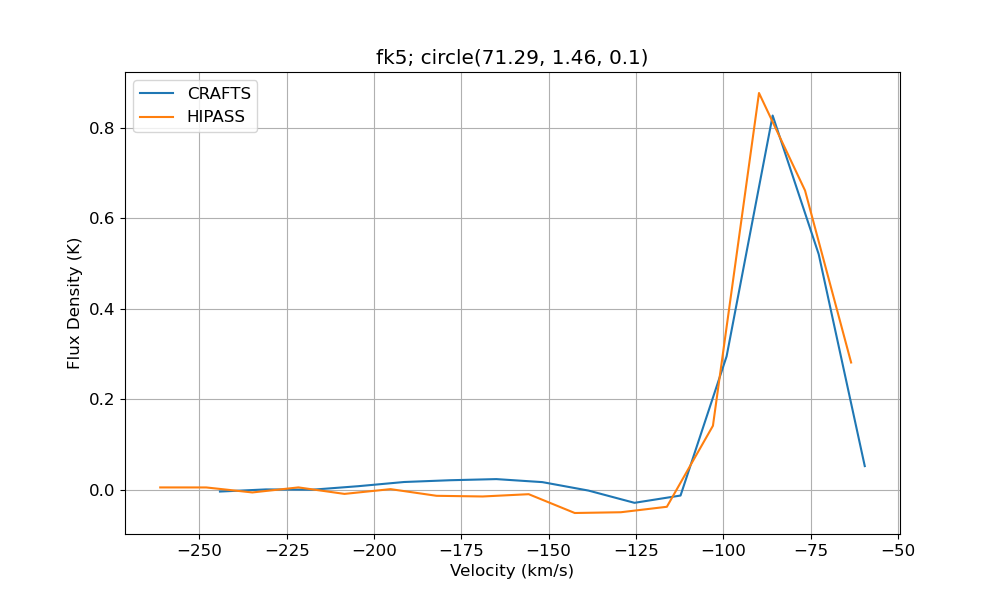

In [15]:
fig = plt.figure(figsize=(10, 6))
plt.plot(velocities, spectrum, label="CRAFTS")
plt.plot(hipass_velocities, hipass_spectrum, label="HIPASS")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux Density (K)")
plt.title(ds9_str)
plt.legend()
plt.grid()
plt.show()